# **Seasona Flu Prediction:**
## **Exploratory Data Analysis:**

### Notebook Purpose:
This Notebook conducts exploratory data anaylis on the cleaned dataset to ;
- Understand feauture distributions
- Identify relationships between feature and target variable 
- Detect outlier
- Genrate insights to inform modelling decisions in the Final Notebook

### **Data Source:** National 2009 HINI Flu Survey.

### Notebook Inputs:
-  `Data/Cleaned_data/cleaned_data.csv`

### Notebook Outputs:
- Visualizations saved to `Images/`
- Key insights to inform feature selection and modeling

## **Library Imports:**

In [4]:
# Overall Imports to be used throughout the analysis

#Standard Libraries
import warnings
warnings.filterwarnings("ignore")

#Core Data Manipulation Libraries
import numpy as np
import pandas as pd

#Data Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

#Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

print("All libraries imported successfully and ready to use")

All libraries imported successfully and ready to use


## **Loading Cleaned Data:**


In [5]:
#Define paths for data and images

cleaned_path = "../Data/Cleaned_data/"
images_path = "../Images/"

#Load the Cleaned Data:

df = pd.read_csv(cleaned_path + "cleaned_data.csv", 
                 index_col="respondent_id")

# Separate numeric and categorical columns
# Exclude target variable seasonal_vaccine to prevent data leakage during preprocessing
numeric_cols = df.select_dtypes(
    include=["float64", "int64"]
).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != "seasonal_vaccine"]

categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print(f" Cleaned data loaded successfully")
print(f"  Shape               : {df.shape}")
print(f"  Numeric Features    : {len(numeric_cols)}")
print(f"  Categorical Features: {len(categorical_cols)}")
print(f"  Target              : seasonal_vaccine")



 Cleaned data loaded successfully
  Shape               : (26707, 36)
  Numeric Features    : 23
  Categorical Features: 12
  Target              : seasonal_vaccine


## **Exploratory Data Analysis:**


## **Feature Distribution:**

I examine the distribution of each feature group separately;
1.  Behavioral features
2.  Opinion features
3.  Demographic features

#### **Behavioral Features:**
Behavioral feauture capture protective actions takes by respondents. 
All behavioral features are binary (0=No, 1=Yes)
I examine their distributions and skewness to understand compliance pattterns across survey population.

In [6]:
#Behavorial Features Skewness Analsysis

#Calculate skewness for each behavioral feature
# Skewness > 1 or < -1 indicates high skewness
# Skewness between -1 and 1 indicates moderate or no skewness
behavioral_cols = [col for col in numeric_cols if col.startswith("behavioral")]
behavioral_skewness = df[behavioral_cols].skew().round(2)

print(" Behavioral Features Skewness")
for col, skew in behavioral_skewness.items():
    if abs(skew) > 1:
        level = "High Skewness"
    elif abs(skew) > 0.5:
        level = "Moderate Skewness"
    else:
        level = "Low Skewness"
    print(f"  {col:<35} : {skew:>6} ({level})")

 Behavioral Features Skewness
  behavioral_antiviral_meds           :   4.19 (High Skewness)
  behavioral_avoidance                :  -1.01 (High Skewness)
  behavioral_face_mask                :    3.4 (High Skewness)
  behavioral_wash_hands               :  -1.72 (High Skewness)
  behavioral_large_gatherings         :   0.59 (Moderate Skewness)
  behavioral_outside_home             :   0.69 (Moderate Skewness)
  behavioral_touch_face               :  -0.76 (Moderate Skewness)


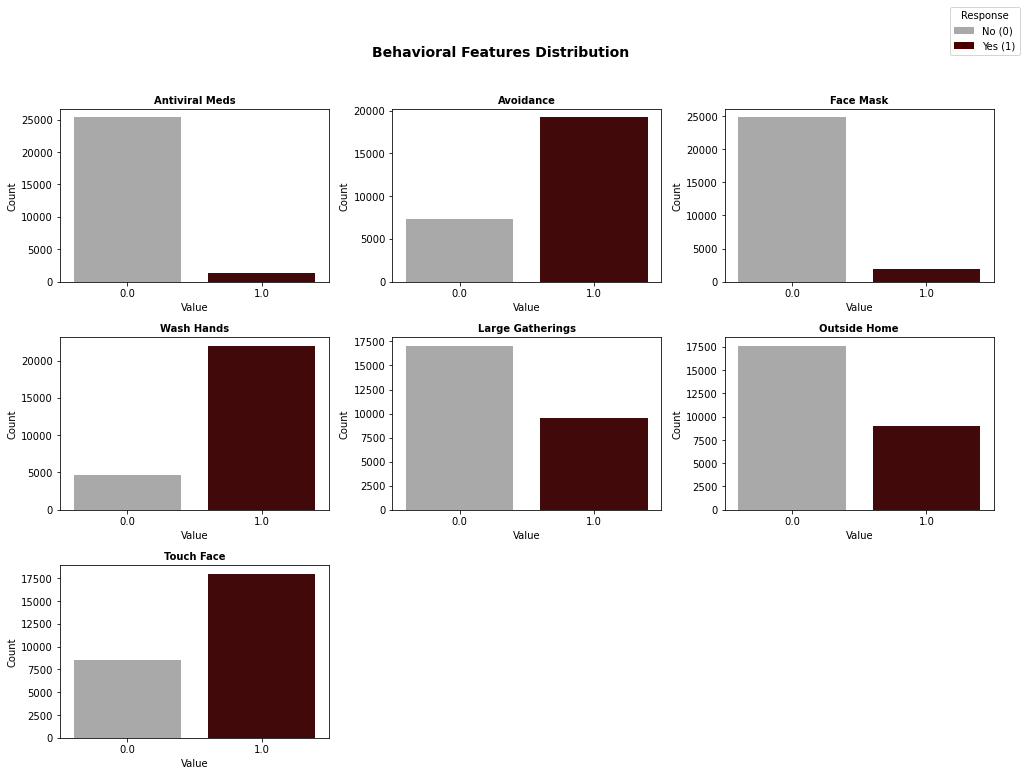

In [7]:
#Behavioral Features Distribution

#Extract only behavioral columns fromnuemric features for focuse analysis
behavioral_cols = [col for col in numeric_cols if col.startswith("behavioral")]

#Creat a grid of histogram subplots one for each behavioral feature to visualize their distributions
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten() #Flatten axes array for easy iteration

# Plot count of each behavioral feature
for i, col in enumerate(behavioral_cols):
    sns.countplot(
        x=df[col],
        ax=axes[i],
        palette=["#A9A9A9", "#4A0000"]
    )
#clean up column names for readable title
    axes[i].set_title(col.replace("behavioral_", "").replace("_", " ").title(),
                      fontsize=10, fontweight="bold")
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")

# Hide any unused subplots since we have 7 features in a 3*3 grid
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Behavioral Features Distribution",
             fontsize=14, fontweight="bold", y=1.02)
# Add single legend for entire figure
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#A9A9A9", label="No (0)"),
    Patch(facecolor="#4A0000", label="Yes (1)")
]
fig.legend(
    handles=legend_elements,
    loc="lower right",
    fontsize=10,
    title="Response",
    bbox_to_anchor=(1.02, 1)  
)
plt.tight_layout()
plt.savefig(images_path + "behavioral_distributions.png",
            dpi=150, bbox_inches="tight")
plt.show()

#### Behavioral Features Observations:
- All behavioral features are binary (0 = No, 1 = Yes) as expected
- **High compliance behaviors:** Wash hands, avoidance and 
  touch face show majority positive behavior (skewed to 1)
- **Low compliance behaviors:** Antiviral meds and face mask 
  show very low uptake (skewed to 0)
- High skewness in antiviral meds and face mask suggests 
  these may have limited predictive power
- No unexpected values detected in any behavioral feature


#### **Opinion Features:**
Opinion features capture respondents views on vaccine 
effectiveness, disease risk and worry about side effects.
These features are ordinal ranging from 1 to 5.
I examine their distributions to understand general 
sentiment across the survey population.


H1N1 Opinion Features     : ['opinion_h1n1_vacc_effective', 'opinion_h1n1_risk', 'opinion_h1n1_sick_from_vacc']
Seasonal Opinion Features : ['opinion_seas_vacc_effective', 'opinion_seas_risk', 'opinion_seas_sick_from_vacc']
 Seasonal Opinion Features Skewness
  opinion_seas_vacc_effective         :  -1.32 (High Skewness)
  opinion_seas_risk                   :   0.25 (Low Skewness)
  opinion_seas_sick_from_vacc         :   0.92 (Moderate Skewness)


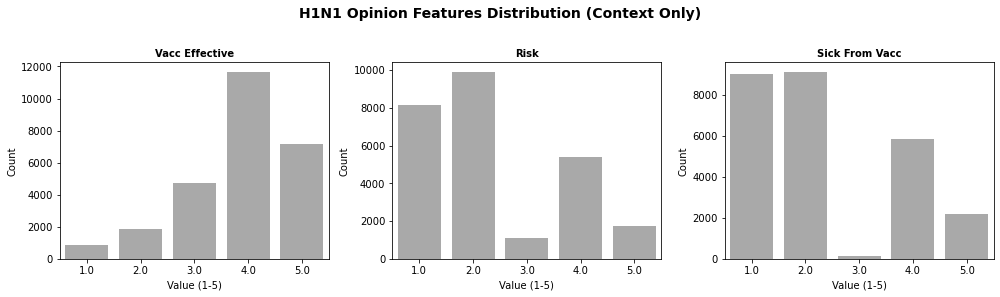

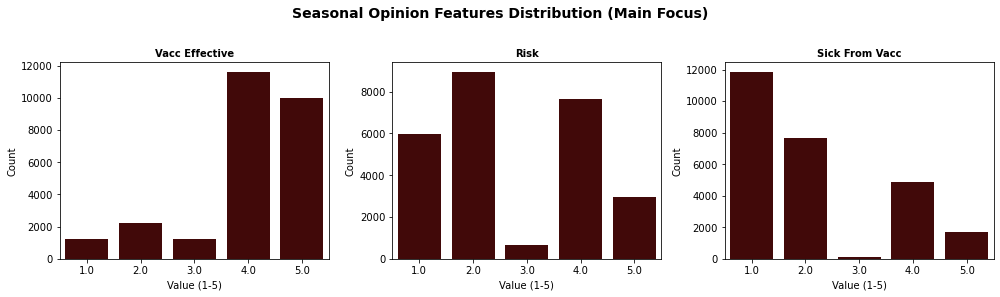

In [8]:

# Opinion Features Distribution


# Extract only opinion columns from numeric features for focused analysis
opinion_cols = [col for col in numeric_cols if col.startswith("opinion")]

# Separate H1N1 and seasonal opinion columns for focused analysis since i am only focusing on the data for seasonal flu
h1n1_opinion_cols = [col for col in opinion_cols if "h1n1" in col]
seas_opinion_cols = [col for col in opinion_cols if "seas" in col]

print(f"H1N1 Opinion Features     : {h1n1_opinion_cols}")
print(f"Seasonal Opinion Features : {seas_opinion_cols}")

# Calculate skewness for seasonal opinion features
seas_opinion_skewness = df[seas_opinion_cols].skew().round(2)

print(" Seasonal Opinion Features Skewness")
for col, skew in seas_opinion_skewness.items():
    if abs(skew) > 1:
        level = "High Skewness"
    elif abs(skew) > 0.5:
        level = "Moderate Skewness"
    else:
        level = "Low Skewness"
    print(f"  {col:<35} : {skew:>6} ({level})")

# Figure 1: H1N1 Opinion Features (context/comparison) 
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes = axes.flatten()

for i, col in enumerate(h1n1_opinion_cols):
    sns.countplot(
        x=df[col],
        ax=axes[i],
        color="#A9A9A9"    
    )
    axes[i].set_title(
        col.replace("opinion_h1n1_", "").replace("_", " ").title(),
        fontsize=10, fontweight="bold"
    )
    axes[i].set_xlabel("Value (1-5)")
    axes[i].set_ylabel("Count")

plt.suptitle("H1N1 Opinion Features Distribution (Context Only)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(images_path + "h1n1_opinion_distributions.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Figure 2: Seasonal Opinion Features (main focus)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes = axes.flatten()

for i, col in enumerate(seas_opinion_cols):
    sns.countplot(
        x=df[col],
        ax=axes[i],
        color="#4A0000"  
    )
    axes[i].set_title(
        col.replace("opinion_seas_", "").replace("_", " ").title(),
        fontsize=10, fontweight="bold"
    )
    axes[i].set_xlabel("Value (1-5)")
    axes[i].set_ylabel("Count")

plt.suptitle("Seasonal Opinion Features Distribution (Main Focus)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(images_path + "seas_opinion_distributions.png",
            dpi=150, bbox_inches="tight")
plt.show()

#### Seasonal Opinion Features Observations:

Seasonal Vaccine Effectiveness (Seas Vacc Effective):
- Majority of respondents believe the seasonal vaccine is 
  effective (values 4 and 5 dominate)
- Very few respondents believe it is not effective (values 1 and 2)
- This is a positive signal - high perceived effectiveness 
  may correlate with higher vaccination uptake

Seasonal Risk (Seas Risk):
- Most respondents perceive low to moderate risk of getting 
  sick without the vaccine (values 1 and 2 dominate)
- Value 3 (Don't know) has very few responses
- Moderate uptick at value 4 suggesting some respondents 
  do perceive meaningful risk
- Low perceived risk may explain why some people choose 
  not to vaccinate

Seasonal Sick From Vaccine (Seas Sick From Vacc):
- Majority of respondents are not worried about getting 
  sick from the vaccine (value 1 dominates strongly)
- Worry decreases as the scale increases
- Low worry about side effects is a positive signal for 
  vaccination uptake

Overall Observation:
- Respondents generally have positive opinions about the 
  seasonal vaccine
- Perceived effectiveness and low worry about side effects 
  are likely strong predictors of vaccination
- These features will be closely watched during modeling 
  for feature importance


### **Demographic Features:**
Demographic features capture the background characteristics 
of respondents including age, education, race, sex, income 
and employment status. These are all categorical features.
I examine their distributions to understand the composition 
of the survey population.


Demographic Features Value Counts

age_group:
65+ Years        6843
55 - 64 Years    5563
45 - 54 Years    5238
18 - 34 Years    5215
35 - 44 Years    3848
Name: age_group, dtype: int64

education:
College Graduate    10097
Some College         7043
12 Years             5797
< 12 Years           2363
Name: education, dtype: int64

race:
White                21222
Black                 2118
Hispanic              1755
Other or Multiple     1612
Name: race, dtype: int64

sex:
Female    15858
Male      10849
Name: sex, dtype: int64

income_poverty:
<= $75,000, Above Poverty    12777
> $75,000                     6810
Below Poverty                 2697
Name: income_poverty, dtype: int64

marital_status:
Married        13555
Not Married    11744
Name: marital_status, dtype: int64

rent_or_own:
Own     18736
Rent     5929
Name: rent_or_own, dtype: int64

employment_status:
Employed              13560
Not in Labor Force    10231
Unemployed             1453
Name: employment_status, dtype: int64

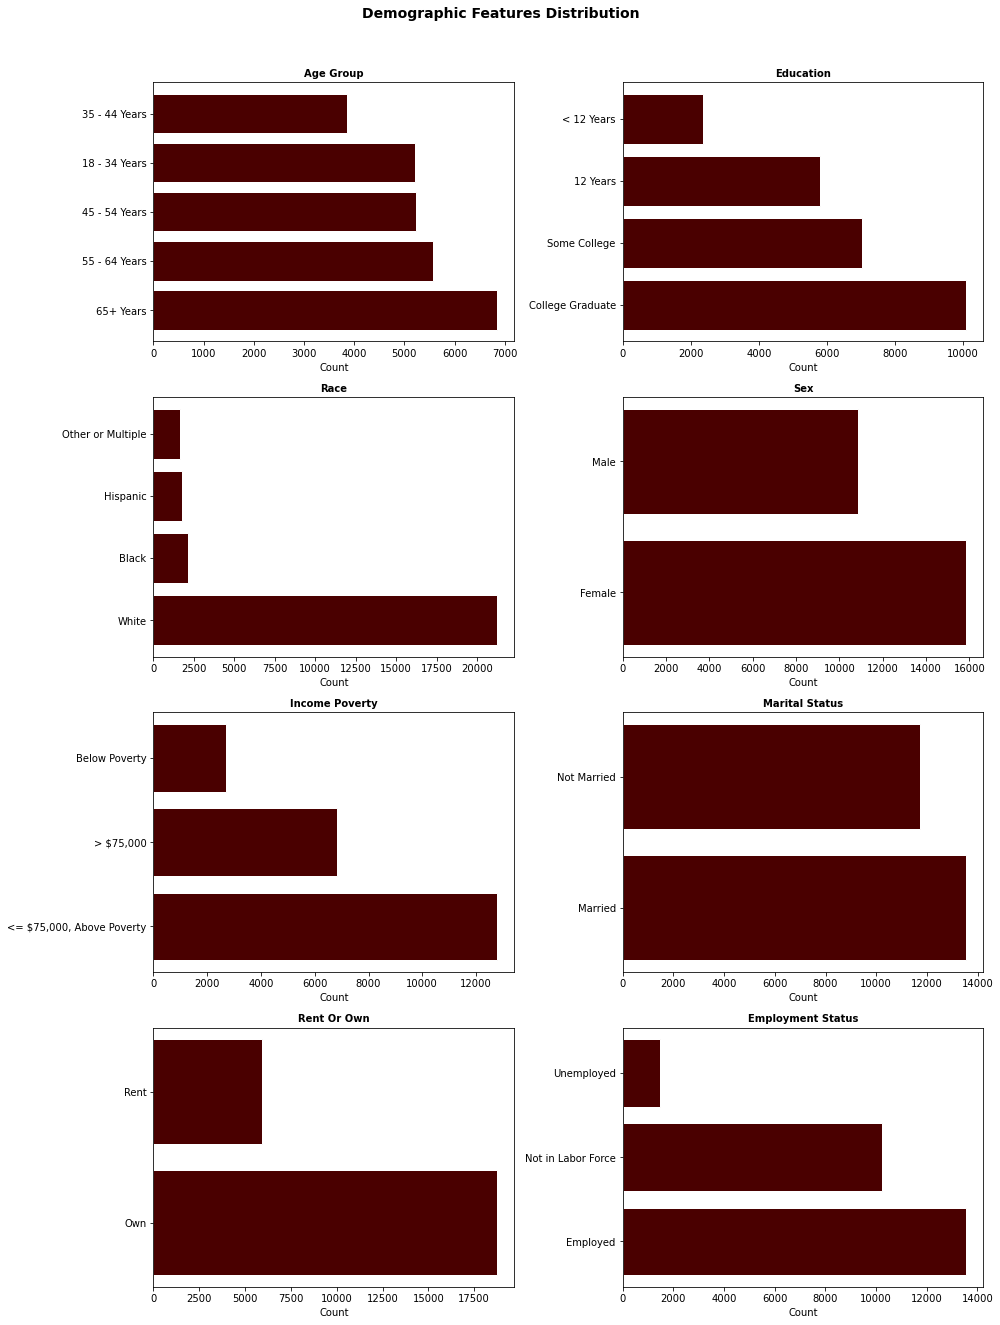

In [9]:
# DEmographic Features Analysis

# Define demographic columns
demographic_cols = [
    "age_group", "education", "race", "sex",
    "income_poverty", "marital_status",
    "rent_or_own", "employment_status"
]

print("Demographic Features Value Counts")
for col in demographic_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()

for i, col in enumerate(demographic_cols):
    value_counts = df[col].value_counts()
    
    axes[i].barh(
        value_counts.index,
        value_counts.values,
        color="#4A0000",
        edgecolor="white"
    )
    axes[i].set_title(
        col.replace("_", " ").title(),
        fontsize=10, fontweight="bold"
    )
    axes[i].set_xlabel("Count")
    axes[i].set_ylabel("")

plt.suptitle("Demographic Features Distribution",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(images_path + "demographic_distributions.png",
            dpi=150, bbox_inches="tight")
plt.show()

#### Demographic Features Observations

Age Group:
- Older respondents dominate the survey population
- 65+ years is the largest group (6,843) followed by 55-64 years (5,563)
- Younger respondents 18-34 years are underrepresented (5,215)
- This is relevant as older populations are higher risk for 
  flu complications and may be more likely to vaccinate

Education:
- College graduates are the largest group (10,097)
- Less than 12 years education is the smallest group (2,363)
- Higher education levels dominate the survey population
- Education level may influence health literacy and 
  vaccination decisions

Race:
- White respondents dominate heavily (21,222 out of 26,707)
- This is a significant limitation of the dataset as it 
  may not represent diverse populations equally
- Results should be interpreted with caution across 
  racial groups

Sex:
- Female respondents outnumber male (15,858 vs 10,849)
- Roughly 59% female and 41% male

Income Poverty:
- Majority are above poverty level (12,777)
- Only 2,697 respondents are below poverty
- Income level may influence access to healthcare and 
  vaccination

Marital Status:
- Fairly balanced between married (13,555) and 
  not married (11,744)

Rent or Own:
- Majority own their home (18,736 vs 5,929 renters)
- Home ownership may be a proxy for socioeconomic stability

Employment Status:
- Employed respondents are the largest group (13,560)
- Not in labor force is second (10,231) which aligns with 
  the older age distribution
- Unemployed is the smallest group (1,453)

Overall Observation:
- The survey population skews older, white, educated 
  and above poverty
- These demographic imbalances are important limitations 
  to acknowledge when applying findings to the 
  Kenyan public health context
- Age and education are likely strong demographic 
  predictors of seasonal flu vaccination

## **Outlier Detection:**
I examine numeric features for outliers using boxplots.
Outliers can affect model performance and will be treated/imputed in the Final Notebook after the train test split

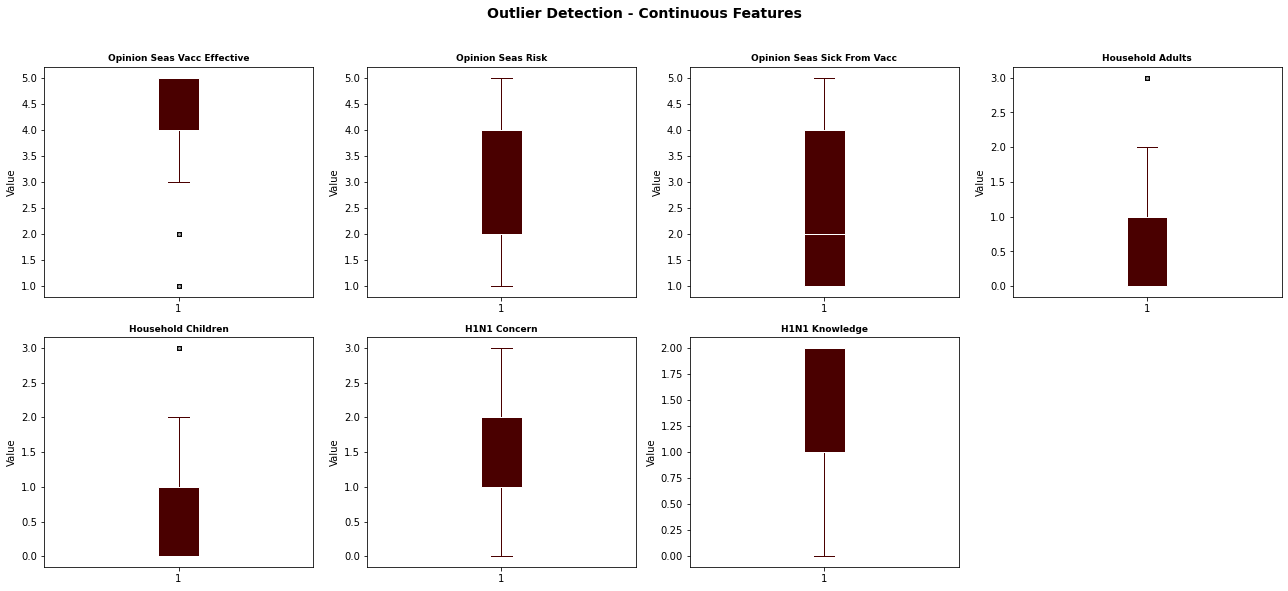

Outlier Summary (IQR Method)
  opinion_seas_vacc_effective         : 3427 outliers
  opinion_seas_risk                   : 0 outliers
  opinion_seas_sick_from_vacc         : 0 outliers
  household_adults                    : 1125 outliers
  household_children                  : 1747 outliers
  h1n1_concern                        : 0 outliers
  h1n1_knowledge                      : 0 outliers


In [10]:
#Outlier Detection

# Focus on continuous numeric features only as binary features cannot have outliers by definition
continuous_cols = [
    "opinion_seas_vacc_effective",
    "opinion_seas_risk",
    "opinion_seas_sick_from_vacc",
    "household_adults",
    "household_children",
    "h1n1_concern",        # may correlate with seasonal vaccine
    "h1n1_knowledge"       #may also correlate with seasonal vaccine since they are related topics
]

# Create boxplots for continuous features
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    axes[i].boxplot(
        df[col].dropna(),
        patch_artist=True,
        boxprops=dict(facecolor="#4A0000", color="white"),
        medianprops=dict(color="white"),
        whiskerprops=dict(color="#4A0000"),
        capprops=dict(color="#4A0000"),
        flierprops=dict(
            marker="o",
            markerfacecolor="#A9A9A9",
            markersize=4
        )
    )
    axes[i].set_title(
        col.replace("_", " ").title(),
        fontsize=9, fontweight="bold"
    )
    axes[i].set_ylabel("Value")
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Outlier Detection - Continuous Features",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(images_path + "outlier_detection.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Print outlier summary using IQR method
print("Outlier Summary (IQR Method)")
for col in continuous_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)][col].count()
    print(f"  {col:<35} : {outliers} outliers")

####  Outlier Detection Observations

Opinion Seas Vacc Effective (3,427 outliers):
- High number of statistical outliers detected
- However these are NOT true outliers — they represent 
  legitimate survey responses
- The distribution is left skewed meaning most respondents 
  rate the vaccine as effective (4 and 5)
- Lower values (1 and 2) appear as statistical outliers 
  but represent genuine minority opinions


Household Adults (1,125 outliers):
- Most respondents live with 0 or 1 other adult
- Households with 2 or 3 adults are flagged as statistical 
  outliers but are perfectly valid living arrangements
- Top coded at 3 meaning no value exceeds 3


Household Children (1,747 outliers):
- Majority of respondents have no children in the household
- Respondents with 1 or more children are flagged as 
  statistical outliers
- Top coded at 3 meaning no value exceeds 3
- This aligns with the older age distribution of the 
  survey population where children have left home


Opinion Seas Risk (0 outliers):
- No outliers detected
- Distribution is fairly spread across all values
- Respondents have varied opinions about seasonal flu risk

Opinion Seas Sick From Vacc (0 outliers):
- No outliers detected
- Most respondents are not worried about getting sick 
  from the vaccine
- Distribution skews towards lower worry values

H1N1 Concern (0 outliers):
- No outliers detected
- Concern levels are fairly distributed across the scale
- Kept for analysis as general flu awareness may correlate 
  with seasonal vaccination behavior

H1N1 Knowledge (0 outliers):
- No outliers detected
- Knowledge levels are distributed across the scale
- Kept for analysis as general flu knowledge may correlate 
  with seasonal vaccination behavior

Overall Outlier Strategy:
- I did not perform any aggressive outlier removal in the Final Notebook as the outliers were genuine survey responses hence valid data points
- All flagged values represent legitimate survey responses
- The IQR method flags values in skewed distributions 
  as outliers even when they are valid
- Scaling in the Final notebook handles distribution 
  differences between features
- This decision protects the integrity of the survey data 
  and avoids removing genuine minority opinions and 
  living situations that may be important predictors 
  of vaccination behavior

## **Feature Vs Target Analysis:**
I examined how each feature relates to our target variable 'seasonal_vaccine'. This helped me to understand which features are likely to be strong predictors during modeling.

I examined three feature groups:
1. Behavioral features vs seasonal vaccine
2. Opinion features vs seasonal vaccine
3. Demographic features vs seasonal vaccine

#### **Behavorial features vs Seasonal vaccine:**


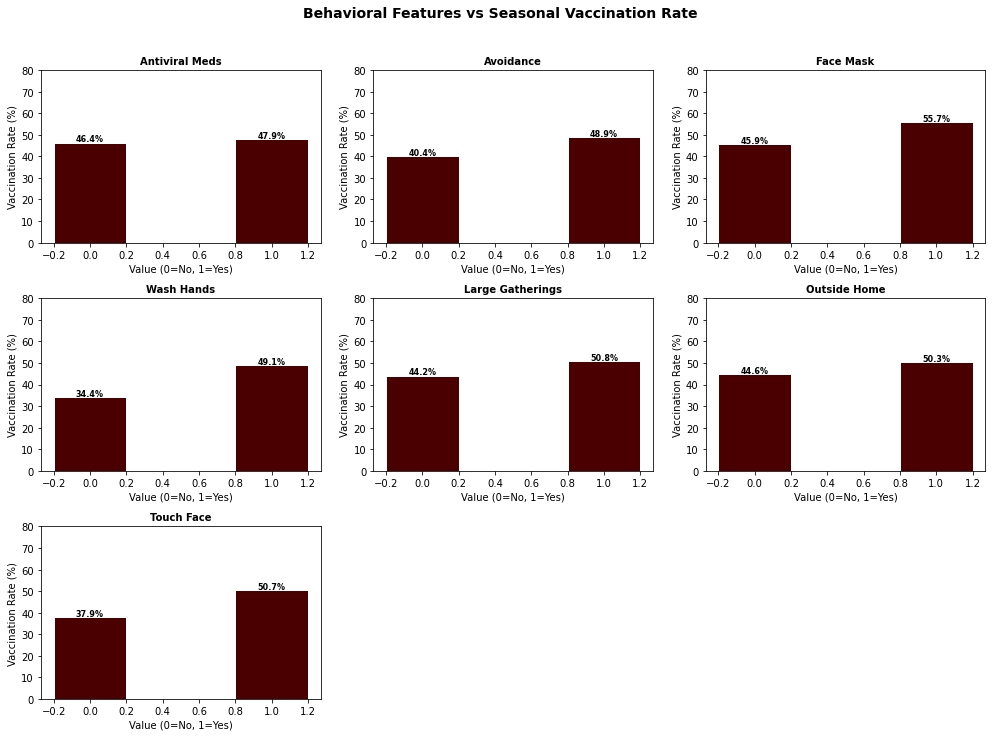

In [11]:
#Behavioral Features vs Seasonal Vaccine

# Calculate seasonal vaccination rate for each behavioral feature
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(behavioral_cols):
    # Calculate vaccination rate for each value of the feature
    vacc_rate = df.groupby(col)["seasonal_vaccine"].mean() * 100
    
    axes[i].bar(
        vacc_rate.index,
        vacc_rate.values,
        color="#4A0000",
        edgecolor="white",
        width=0.4
    )
    # Add percentage labels on top of bars
    for x, y in zip(vacc_rate.index, vacc_rate.values):
        axes[i].text(
            x, y + 0.5,
            f"{y:.1f}%",
            ha="center",
            fontsize=8,
            fontweight="bold",
            color="black"
        )
    axes[i].set_title(
        col.replace("behavioral_", "").replace("_", " ").title(),
        fontsize=10, fontweight="bold"
    )
    axes[i].set_xlabel("Value (0=No, 1=Yes)")
    axes[i].set_ylabel("Vaccination Rate (%)")
    axes[i].set_ylim(0, 80)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    "Behavioral Features vs Seasonal Vaccination Rate",
    fontsize=14, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig(images_path + "behavioral_vs_target.png",
            dpi=150, bbox_inches="tight")
plt.show()

#### Behavioral Features Vs Seasonal Vaccine Observations:

Antiviral Meds(46.4% No vs 47.9% Yes):
- Is most likey a weak predictor highlighted by the almost no difference in vaccination rate.
- Whether someone took antiviral meds has very little influence on seasonal vaccination.

Avoidance (40.4% No vs 48.9% Yes):
- Moderate difference-people who avoided contact with flu patients are more likely to vaccinate suggesting that health conscious behavior correlates with vaccination.

Face Mask(45,9% No Vs 55.7% Yes):
- There is a noticable difference i.e. people who bought face masks are more likely to vaccinate suggesting that general flu protective behavior correlates with vaccination uptake.

Wah Hands (34.4% No vs 49.1% No):
- There is a strong difference as people who frequently wash hands are significantly more likely to vaccinate and therefore proving to be a stronger behavioral predictors.

Large Gatherings(44.2% No vs 50.8% Yes):
- There is a strong difference i.e. people who reduced large gathering are more likely to vaccinate suggesting risk awareness often drives both behaviors.

Outside Home(44.6% No vs 50.3% Yes):
- Moderate difference- people who reduced outside contact were more likely to vaccinate showing a similar pattern to the Large gatherings feature.

Touch Facce(37.9% No vs 50.7% Yes):
Strong Difference: people who avoided touching their faces were significantly more likely to vaccinate hence being one of the stronger behavioral predictors features.

Overall Behavioral Observations:
- All behavioral features show a positive relationship 
  with seasonal vaccination
- People who practice protective behaviors are 
  consistently more likely to vaccinate
- **Strongest predictors:** Wash hands and touch face
- **Weakest predictor:** Antiviral meds
- This suggests that general health consciousness 
  is a strong driver of seasonal flu vaccination


#### **Opinion Features Vs Seasonal Vaccine:**

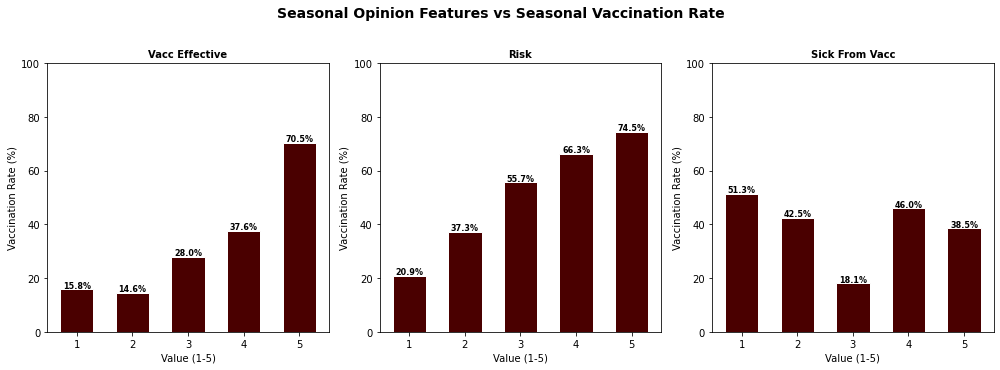

In [12]:
#Seasonal Opinions Features Vs Seasonal Vaccine(target)

# Calculate seasonal vaccination rate for each seasonal opinion feature
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes = axes.flatten()

for i, col in enumerate(seas_opinion_cols):
    vacc_rate = df.groupby(col)["seasonal_vaccine"].mean() * 100
    
    axes[i].bar(
        vacc_rate.index,
        vacc_rate.values,
        color="#4A0000",
        edgecolor="white",
        width=0.6
    )
    for x, y in zip(vacc_rate.index, vacc_rate.values):
        axes[i].text(
            x, y + 0.5,
            f"{y:.1f}%",
            ha="center",
            fontsize=8,
            fontweight="bold",
            color="black"
        )
    axes[i].set_title(
        col.replace("opinion_seas_", "").replace("_", " ").title(),
        fontsize=10, fontweight="bold"
    )
    axes[i].set_xlabel("Value (1-5)")
    axes[i].set_ylabel("Vaccination Rate (%)")
    axes[i].set_ylim(0, 100)

plt.suptitle(
    "Seasonal Opinion Features vs Seasonal Vaccination Rate",
    fontsize=14, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig(images_path + "opinion_vs_target.png",
            dpi=150, bbox_inches="tight")
plt.show()


#### Seasonal Opinion Features vs Seasonal Vaccine Observations:

Vaccine Effectiveness (Vac Effective):
- Shows a very strong and positive relationship as belief in vaccine effectiveness increases so does vaccination rate dramatically.
- Not effective(1): only 15.8% vaccinated
- Very effective(0): 70.5% vaccinated
- This is likely one of the strongest predictors in the entire dataset.

Seasonal Risk(Risk):
- Strong postive relationship as perceived risk of getting sick without vaccine increases so does vaccination rate.
- Very low risk(1):only 20.9% vaccinated
- Very high risk(0): 74.5% vaccinated

Sick From Vaccine(Sick from Vacc):
- This feature shows the most nuanced and unexpected 
  pattern of all opinion features
- Not worried (1): 51.3% vaccinated - highest rate
- Not very worried (2): 42.5% vaccinated - drops notably
- Don't know (3): only 18.1% vaccinated - lowest rate
- Somewhat worried (4): 46.0% vaccinated - rises again
- Very worried (5): 38.5% vaccinated - drops again
- The pattern is not linear which is unusual and 
  worth noting
- The "Don't know" group at value 3 has by far the 
  lowest vaccination rate of 18.1%, lower even than 
  people who are very worried about side effects
- This suggests that **uncertainty and lack of information** 
  about vaccine side effects is a more significant 
  barrier to vaccination than actual concern or worry
- People who are worried (4 and 5) have actually made 
  an informed assessment of the risk i.e. they know about 
  side effects and have formed an opinion
- People who don't know (3) have not yet engaged with 
  the information at all and are therefore least 
  likely to vaccinate
- This has important implications i.e. vaccination campaigns 
  should focus on **informing** people about side effects 
  rather than simply reassuring them

Overall:

- Opinion features show the strongest relationships 
  with seasonal vaccination of all feature groups
- Strongest predictors appear to be vaccine 
  effectiveness and perceived risk

#### **Demographic Features vs Sesaonal Vaccine:**

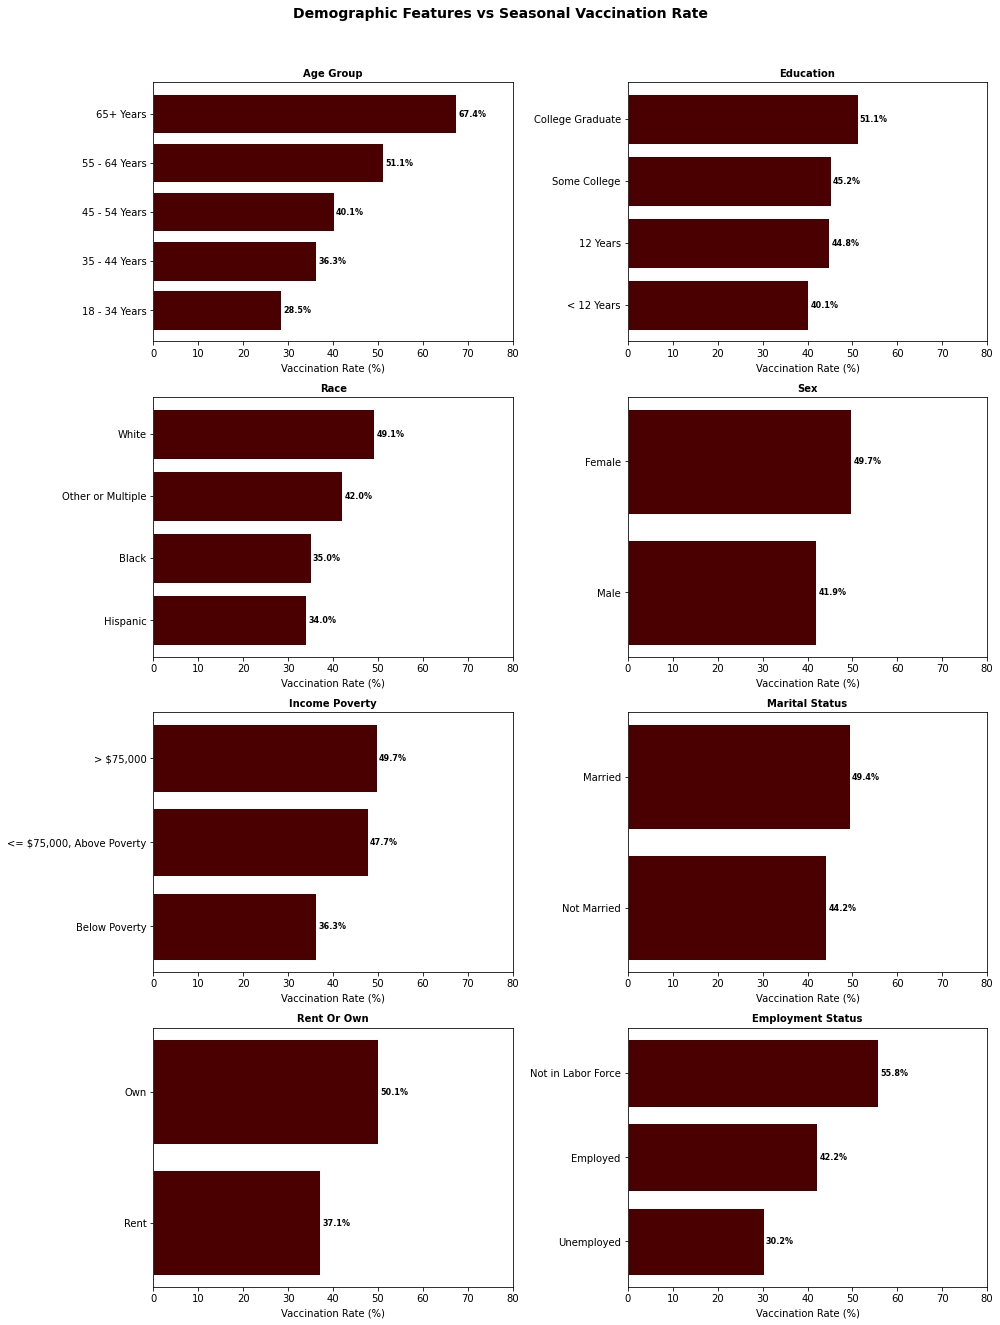

In [13]:
#Demographic Features vs Seasona Vaccine(target)

# Calculated seasonal vaccination rate for each demographic feature
fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()

for i, col in enumerate(demographic_cols):
    vacc_rate = df.groupby(col)["seasonal_vaccine"].mean() * 100
    
    vacc_rate = vacc_rate.sort_values(ascending=True)
    
    axes[i].barh(
        vacc_rate.index,
        vacc_rate.values,
        color="#4A0000",
        edgecolor="white"
    )
    for x, y in zip(vacc_rate.values, vacc_rate.index):
        axes[i].text(
            x + 0.5,
            y,
            f"{x:.1f}%",
            va="center",
            fontsize=8,
            fontweight="bold",
            color="black"
        )
    axes[i].set_title(
        col.replace("_", " ").title(),
        fontsize=10, fontweight="bold"
    )
    axes[i].set_xlabel("Vaccination Rate (%)")
    axes[i].set_ylabel("")
    axes[i].set_xlim(0, 80)

plt.suptitle(
    "Demographic Features vs Seasonal Vaccination Rate",
    fontsize=14, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig(images_path + "demographic_vs_target.png",
            dpi=150, bbox_inches="tight")
plt.show()

#### Demographic Features vs Seasonal Vaccine Observations

Age Group:
- Strongest demographic predictor of seasonal vaccination
- Very clear positive relationship with age
- 18-34 Years: only 28.5% vaccinated
- 65+ Years: 67.4% vaccinated
- Almost 40 percentage point difference between 
  youngest and oldest groups
- Older populations are both higher risk and more 
  likely to vaccinate

Education:
- Moderate relationship with vaccination
- Less than 12 Years: 40.1% vaccinated
- College Graduate: 51.1% vaccinated
- Roughly 11 percentage point difference
- Higher education correlates with higher vaccination
- However the relationship is not as strong as age

Race:
- Notable differences across racial groups
- White: 49.1% vaccinated - highest rate
- Hispanic: 34.0% vaccinated - lowest rate
- Black: 35.0% vaccinated
- Other or Multiple: 42.0% vaccinated
- Racial disparities in vaccination rates are present
- Important limitation to acknowledge given the 
  dataset is predominantly white

Sex:
- Small but consistent difference
- Female: 49.7% vaccinated
- Male: 41.9% vaccinated
- Roughly 8 percentage point difference
- Females are slightly more likely to vaccinate

Income Poverty:
- Clear relationship between income and vaccination
- Below Poverty: 36.3% vaccinated - lowest rate
- Above Poverty: 47.7% vaccinated
- Greater than $75,000: 49.7% vaccinated - highest rate
- Lower income correlates with lower vaccination rates
- Likely reflects barriers to healthcare access

Marital Status:
- Small difference
- Married: 49.4% vaccinated
- Not Married: 44.2% vaccinated
- Roughly 5 percentage point difference
- Moderate predictor at best

Rent or Own:
- Moderate difference
- Own: 50.1% vaccinated
- Rent: 37.1% vaccinated
- Roughly 13 percentage point difference
- Home ownership as a proxy for socioeconomic 
  stability shows meaningful difference

Employment Status:
- Interesting and important pattern
- Not in Labor Force: 55.8% vaccinated - highest rate
- Employed: 42.2% vaccinated
- Unemployed: 30.2% vaccinated - lowest rate
- Not in labor force aligns with the older age 
  distribution - retired people vaccinate more
- Unemployed having the lowest rate likely reflects 
  lack of health insurance and healthcare access
- Important intersection with income poverty findings

Overall Demographic Observations:
- Age group is the strongest demographic predictor
- Income, employment status and rent or own suggest 
  socioeconomic barriers to vaccination
- Racial disparities are present and important 
  to acknowledge
- Younger, lower income, unemployed and renting 
  populations are consistently less likely to vaccinate
- These demographic patterns will directly inform 
  stakeholder recommendations

## **CORRELATION MATRIX:**

I examined correlations between all numeric features and our target variable seasonal_vaccine. This helped to:

- Identify which features are most correated with the target.
- Identify multicollinearity between features.
- Inform feature seletion decisions

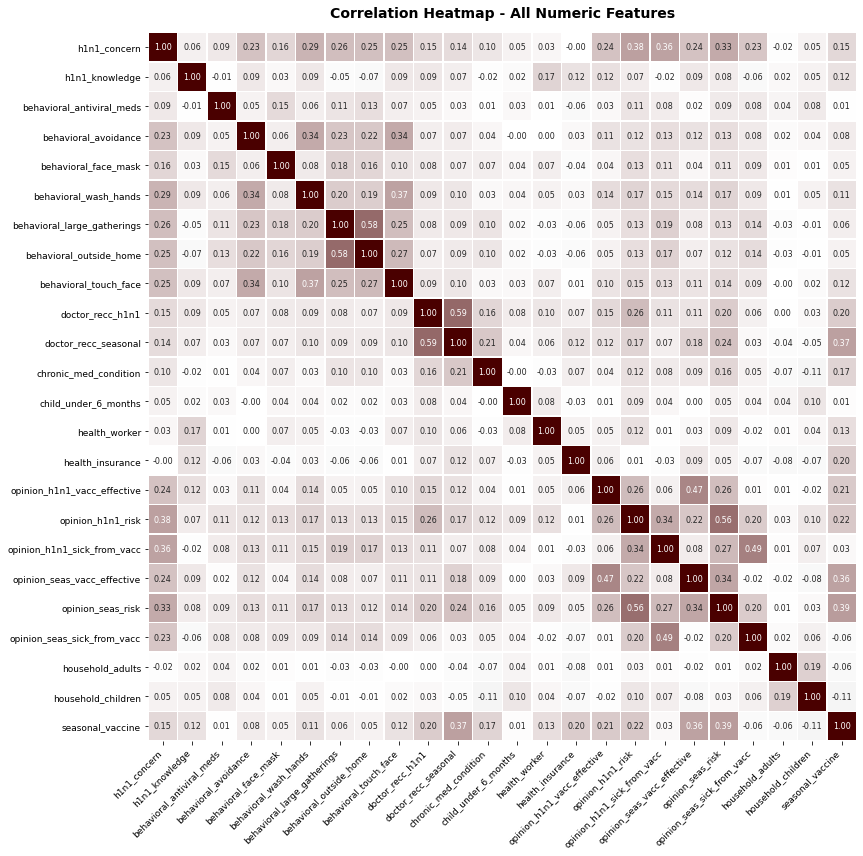

 Correlations with Seasonal Vaccine - All Features 
  opinion_seas_risk                   :  0.390 (Strong)
  doctor_recc_seasonal                :  0.369 (Strong)
  opinion_seas_vacc_effective         :  0.362 (Strong)
  opinion_h1n1_risk                   :  0.217 (Strong)
  opinion_h1n1_vacc_effective         :  0.205 (Strong)
  health_insurance                    :  0.201 (Strong)
  doctor_recc_h1n1                    :  0.199 (Strong)
  chronic_med_condition               :  0.170 (Strong)
  h1n1_concern                        :  0.155 (Strong)
  health_worker                       :  0.127 (Strong)
  behavioral_touch_face               :  0.120 (Strong)
  h1n1_knowledge                      :  0.120 (Strong)
  behavioral_wash_hands               :  0.112 (Strong)
  behavioral_avoidance                :  0.076 (Moderate)
  behavioral_large_gatherings         :  0.064 (Moderate)
  behavioral_outside_home             :  0.054 (Moderate)
  behavioral_face_mask                :  0.050

In [14]:
#Creating a correaltion heatmapf for numeric features to see how they relate to each other and the target variable seasona_vaccine.

#Includes the target variable to see correlatiions with seasonal_vaccine.
corr_matrix = df[numeric_cols + ["seasonal_vaccine"]].corr()

# Correlation heatmap
corr_matrix = df[numeric_cols + ["seasonal_vaccine"]].corr()

# Create custom dark maroon colormap
from matplotlib.colors import LinearSegmentedColormap
custom_cmap = LinearSegmentedColormap.from_list(
    "custom",
    ["#A9A9A9", "#FFFFFF", "#4A0000"]
)

fig, ax = plt.subplots(figsize=(16, 12))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap=custom_cmap,
    center=0,
    square=True,
    linewidths=0.5,
    linecolor="white",
    annot_kws={"size": 8},
    cbar=False,
    ax=ax
)

ax.set_title(
    "Correlation Heatmap - All Numeric Features",
    fontsize=14, fontweight="bold", pad=15
)

plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(images_path + "correlation_heatmap_all.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Print correlations with seasonal vaccine
print(" Correlations with Seasonal Vaccine - All Features ")
target_corr_all = corr_matrix["seasonal_vaccine"].drop(
    "seasonal_vaccine"
).sort_values(ascending=False)

for col, corr in target_corr_all.items():
    if abs(corr) > 0.1:
        level = "Strong"
    elif abs(corr) > 0.05:
        level = "Moderate"
    else:
        level = "Weak"
    print(f"  {col:<35} : {corr:>6.3f} ({level})")

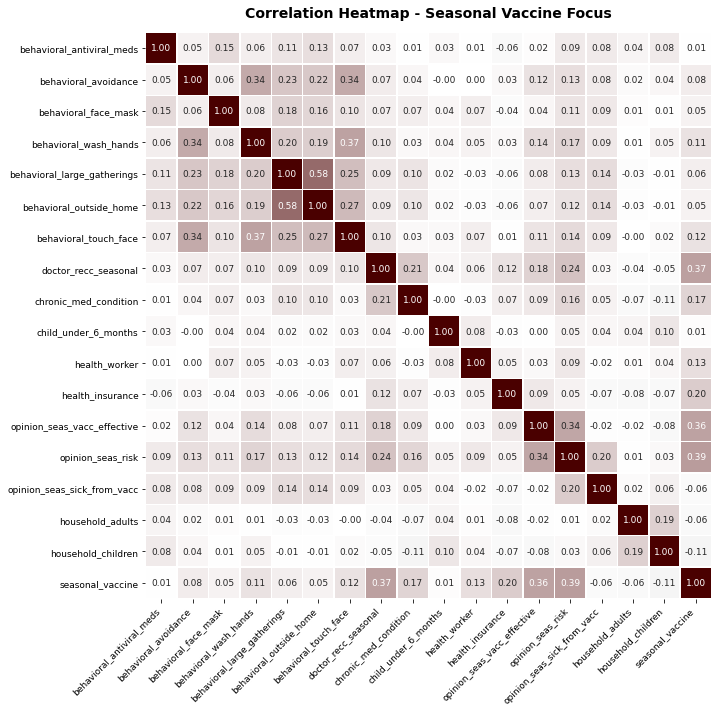

Correlations with Seasonal Vaccine - Seasonal Focus
  opinion_seas_risk                   :  0.390 (Strong)
  doctor_recc_seasonal                :  0.369 (Strong)
  opinion_seas_vacc_effective         :  0.362 (Strong)
  health_insurance                    :  0.201 (Strong)
  chronic_med_condition               :  0.170 (Strong)
  health_worker                       :  0.127 (Strong)
  behavioral_touch_face               :  0.120 (Strong)
  behavioral_wash_hands               :  0.112 (Strong)
  behavioral_avoidance                :  0.076 (Moderate)
  behavioral_large_gatherings         :  0.064 (Moderate)
  behavioral_outside_home             :  0.054 (Moderate)
  behavioral_face_mask                :  0.050 (Moderate)
  child_under_6_months                :  0.012 (Weak)
  behavioral_antiviral_meds           :  0.006 (Weak)
  opinion_seas_sick_from_vacc         : -0.062 (Moderate)
  household_adults                    : -0.065 (Moderate)
  household_children                  : -0.1

In [15]:
#The first correlation heatmap includes all numeric features to provide a comprehnsive overview

# Defining seasonal and general features only
#Excluding H1NI1 specific opinion features.

seasonal_focus_cols = [
    "behavioral_antiviral_meds", "behavioral_avoidance",
    "behavioral_face_mask", "behavioral_wash_hands",
    "behavioral_large_gatherings", "behavioral_outside_home",
    "behavioral_touch_face", "doctor_recc_seasonal",
    "chronic_med_condition", "child_under_6_months",
    "health_worker", "health_insurance",
    "opinion_seas_vacc_effective", "opinion_seas_risk",
    "opinion_seas_sick_from_vacc", "household_adults",
    "household_children", "seasonal_vaccine"
]

# Correlation matrix for seasonal focus features
corr_matrix_seas = df[seasonal_focus_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(
    corr_matrix_seas,
    annot=True,
    fmt=".2f",
    cmap=custom_cmap,
    center=0,
    square=True,
    linewidths=0.5,
    linecolor="white",
    annot_kws={"size": 9},
    cbar=False,
    ax=ax
)

ax.set_title(
    "Correlation Heatmap - Seasonal Vaccine Focus",
    fontsize=14, fontweight="bold", pad=15
)

plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(images_path + "correlation_heatmap_seasonal.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Print correlations with seasonal vaccine only
print("Correlations with Seasonal Vaccine - Seasonal Focus")
target_corr_seas = corr_matrix_seas["seasonal_vaccine"].drop(
    "seasonal_vaccine"
).sort_values(ascending=False)

for col, corr in target_corr_seas.items():
    if abs(corr) > 0.1:
        level = "Strong"
    elif abs(corr) > 0.05:
        level = "Moderate"
    else:
        level = "Weak"
    print(f"  {col:<35} : {corr:>6.3f} ({level})")

#### **Correlation Heatmap Observations**

**Strong Positive Correlations with Seasonal Vaccine:**
- `opinion_seas_risk` (0.390) - strongest predictor
- `doctor_recc_seasonal` (0.369) - second strongest
- `opinion_seas_vacc_effective` (0.362) - third strongest
- `health_insurance` (0.201)
- `chronic_med_condition` (0.170)
- `health_worker` (0.127)
- `behavioral_touch_face` (0.120)
- `behavioral_wash_hands` (0.112)

**Moderate Correlations with Seasonal Vaccine:**
- `behavioral_avoidance` (0.076)
- `behavioral_large_gatherings` (0.064)
- `behavioral_outside_home` (0.054)
- `behavioral_face_mask` (0.050)

**Weak Correlations with Seasonal Vaccine:**
- `child_under_6_months` (0.012) - very weak
- `behavioral_antiviral_meds` (0.006) - negligible

**Negative Correlations with Seasonal Vaccine:**
- `opinion_seas_sick_from_vacc` (-0.062) - slight negative
- `household_adults` (-0.065) - slight negative
- `household_children` (-0.115) - moderate negative
- Having more children in household is associated 
  with lower seasonal vaccination rates
- Aligns with younger age groups being less likely 
  to vaccinate

**Multicollinearity Observations:**
- No severe multicollinearity detected between 
  seasonal focus features
- `doctor_recc_seasonal` and `opinion_seas_vacc_effective`
  show moderate correlation (0.21) but not concerning
- Did VIF scores during modeling in 
  the Final notebook to confirm the two features that had multicollinearity that was not severe.

## **Feature Selection Decisions:**

Based on our analysis I made the following evidence 
based feature selection decisions for predicting 
seasonal flu vaccination only:

**Features to KEEP:**

 Feature : Reason 

- `opinion_seas_risk` : Strongest predictor (0.390) 
- `doctor_recc_seasonal` : Second strongest predictor (0.369) 
-  `opinion_seas_vacc_effective` : Third strongest predictor (0.362) 
-  `health_insurance` : Strong predictor (0.201) 
-  `chronic_med_condition` : Strong predictor (0.170) 
-  `health_worker` : Strong predictor (0.127) 
-  `behavioral_touch_face` : Strong predictor (0.120) 
-  `behavioral_wash_hands` : Strong predictor (0.112) 
-  `opinion_seas_sick_from_vacc` : Informative negative predictor 
-  `behavioral_avoidance` : Moderate predictor (0.076) 
-  `behavioral_large_gatherings` : Moderate predictor (0.064) 
-  `behavioral_outside_home` : Moderate predictor (0.054) 
-  `behavioral_face_mask` : Moderate predictor (0.050) 
-  `household_children` : Negative predictor (-0.115) 
-  `age_group` : Strongest demographic predictor 
- `education` : Moderate demographic predictor 
-  `income_poverty` : Reflects healthcare access barriers 
-  `employment_status` : Reflects healthcare access barriers 
-  `rent_or_own` : Proxy for socioeconomic stability 
-  `marital_status` : Moderate demographic predictor 
- `sex` : Small but consistent predictor 

**Features to DROP:**

 Feature : Reason 

-  `h1n1_concern` : H1N1 specific - out of scope 
-  `h1n1_knowledge` : H1N1 specific - out of scope 
-  `doctor_recc_h1n1` : H1N1 specific - out of scope 
-  `opinion_h1n1_vacc_effective` : H1N1 specific - out of scope 
-  `opinion_h1n1_risk` : H1N1 specific - out of scope 
-  `opinion_h1n1_sick_from_vacc` : H1N1 specific - out of scope 
-  `behavioral_antiviral_meds` : Negligible correlation (0.006) 
-  `child_under_6_months` : Very weak correlation (0.012) 
-  `hhs_geo_region` : Random character strings 
-  `employment_industry` : 49.91% missing, random strings 
- `employment_occupation` : 50.44% missing, random strings 
- `census_msa` : Captured by other geographic features 
- `race` : Not transferable to Kenyan context 
 `household_adults` : Weak negative predictor (-0.065) 

These decisions will be implemented in the Final 
notebook during data preparation after the train 
test split.